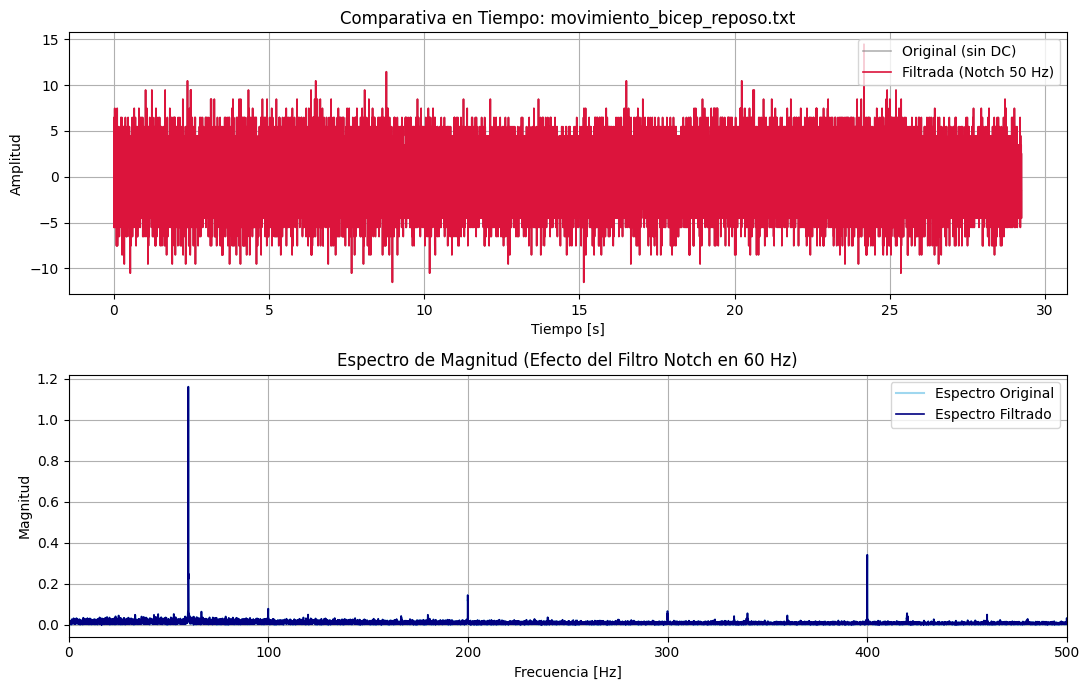

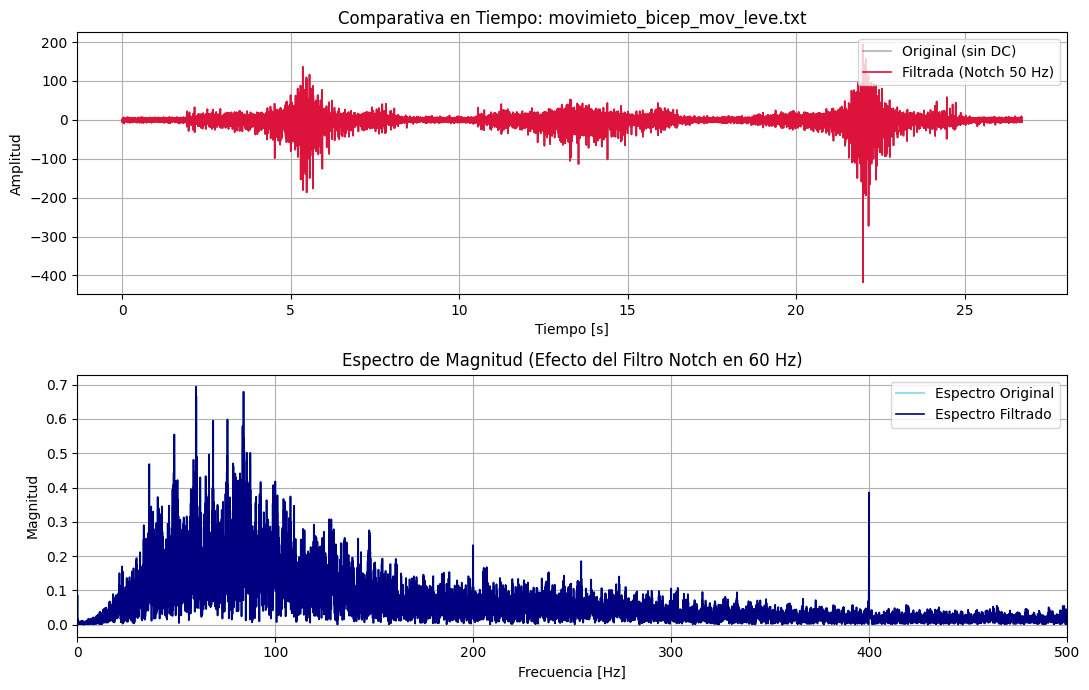

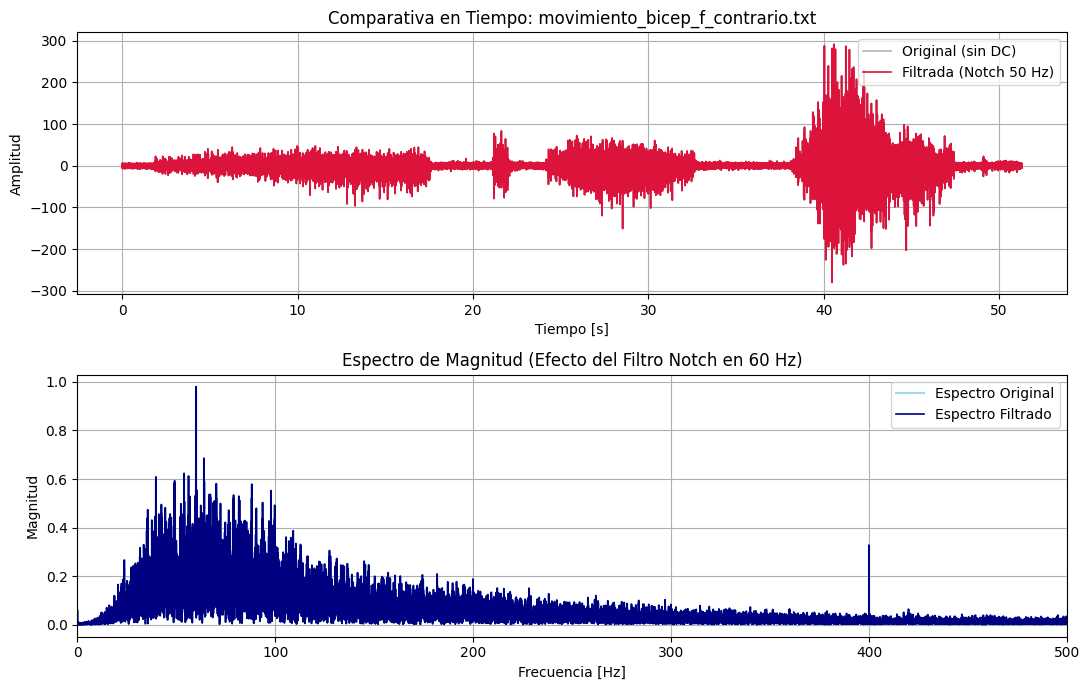

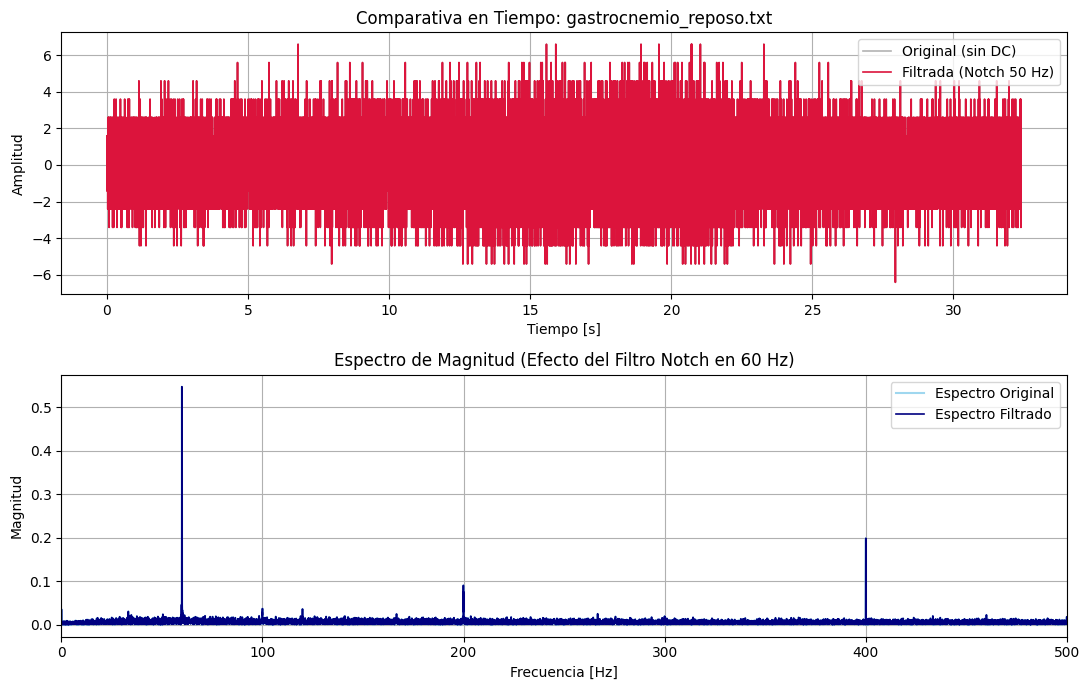

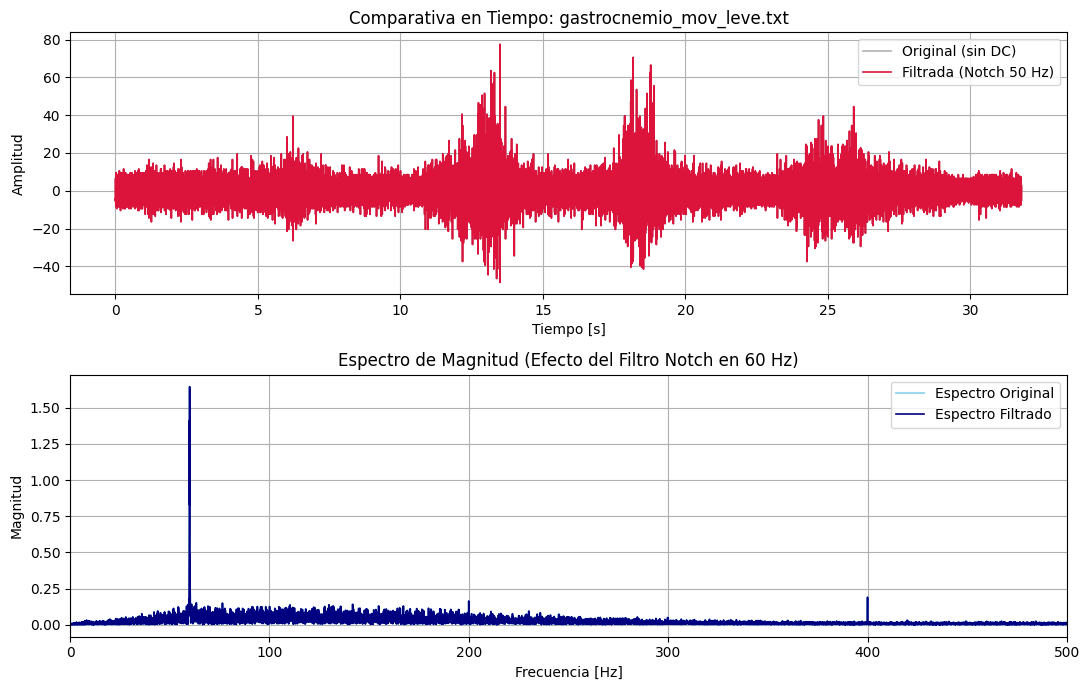

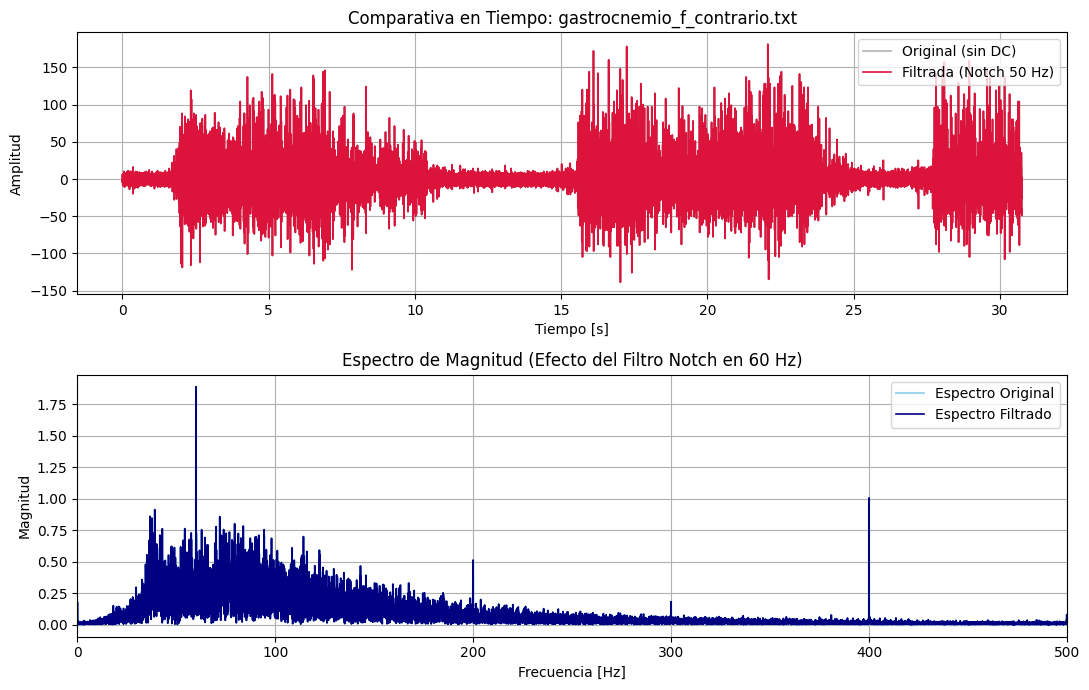

In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import filtfilt, iirnotch

archivos = [
    "movimiento_bicep_reposo.txt",
    "movimieto_bicep_mov_leve.txt",
    "movimiento_bicep_f_contrario.txt",
    "gastrocnemio_reposo.txt",
    "gastrocnemio_mov_leve.txt",
    "gastrocnemio_f_contrario.txt",
]

# parámetros
fs = 1000
f_notch = 60
Q = 30.0
canal_idx = 5

# filtro Notch
w0 = f_notch / (fs / 2)
bw = w0 / Q
b, a = iirnotch(w0, bw)

for nombre_archivo in archivos:

    datos = np.loadtxt(nombre_archivo)
    canal = datos[:, canal_idx]

    # remover componente DC
    canal_sin_dc = canal - np.mean(canal)

    # filtro Notch
    canal_filtrado = filtfilt(b, a, canal_sin_dc)

    # señal Original sin DC
    N = len(canal_sin_dc)
    fft_vals_orig = np.fft.fft(canal_sin_dc)
    fft_mag_orig = np.abs(fft_vals_orig) / N

    # espectro de magnitud
    fft_vals_filt = np.fft.fft(canal_filtrado)
    fft_mag_filt = np.abs(fft_vals_filt) / N

    freqs = np.fft.fftfreq(N, d=1 / fs)

    mask = freqs >= 0
    freqs = freqs[mask]
    fft_mag_orig = fft_mag_orig[mask]
    fft_mag_filt = fft_mag_filt[mask]

    t = np.arange(N) / fs

    # graficas:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))


    ax1.plot(
        t,
        canal_sin_dc,
        color="gray",
        linewidth=1.2,
        alpha=0.6,
        label="Original (sin DC)",
    )
    ax1.plot(
        t,
        canal_filtrado,
        color="crimson",
        linewidth=1.2,
        label="Filtrada (Notch 50 Hz)",
    )
    ax1.set_xlabel("Tiempo [s]")
    ax1.set_ylabel("Amplitud")
    ax1.set_title(f"Comparativa en Tiempo: {nombre_archivo}")
    ax1.legend(loc="upper right")
    ax1.grid(True)

    # original vs filtrada
    ax2.plot(
        freqs,
        fft_mag_orig,
        color="skyblue",
        alpha=0.8,
        label="Espectro Original",
    )
    ax2.plot(
        freqs,
        fft_mag_filt,
        color="navy",
        linewidth=1.2,
        label="Espectro Filtrado",
    )
    ax2.set_xlabel("Frecuencia [Hz]")
    ax2.set_ylabel("Magnitud")
    ax2.set_title(f"Espectro de Magnitud (Efecto del Filtro Notch en {f_notch} Hz)")
    ax2.set_xlim([0, fs / 2])
    ax2.legend(loc="upper right")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()